# Week 06 — Assessment: ML Pipeline Practical + Evaluation Report + Defense

Loan-default classification: baseline → logistic regression → decision tree → random forest,
with a train-only imputation step, full metric comparison, error analysis, and calibration check.

**How this notebook is organized** (mirrors the assessment's required pipeline steps):

1. Setup (given, unmodified)
2. Step 1 — Build features
3. Step 2 — Split *before* touching missing values
4. Step 3 — Impute `credit_score` using train only
5. Step 4 — Baseline
6. Step 5 — Logistic regression, decision tree, random forest
7. Step 6 — Metrics for all four models
8. Step 7 — Error analysis
9. Step 8 — Calibration
10. Write required output files (`model_metrics.json`, two charts, report, defense)


## Imports

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve
from pathlib import Path

RANDOM_STATE = 42

In [2]:
Path("graphs").mkdir(parents=True, exist_ok=True)
Path("metrics").mkdir(parents=True, exist_ok=True)

## Setup (given — run exactly as provided)

This generates the loan-application dataset: 1,200 applicants, whether each defaulted, and four
predictors (`credit_score`, `applicant_income`, `loan_amount`, `employment_type`). 90 `credit_score`
values are missing, simulating bureau data that isn't always available for an applicant — that's
the first real decision in this pipeline: **when** do we fill those in, and using **what**?

In [3]:
rng = np.random.default_rng(seed=55)
n = 1200

employment_type = rng.choice(["Salaried", "Self-Employed", "Contract"], size=n, p=[0.5, 0.28, 0.22])
credit_score = rng.normal(650, 60, size=n).clip(300, 850).round(0)
applicant_income = rng.normal(55000, 20000, size=n).clip(15000, None).round(0)
loan_amount = rng.normal(15000, 7000, size=n).clip(1000, None).round(0)

loan_to_income = loan_amount / applicant_income
emp_risk = pd.Series(employment_type).map({"Salaried": 0, "Self-Employed": 0.3, "Contract": 0.6}).values
z = (-0.035 * (credit_score - 650) + 4.5 * loan_to_income + emp_risk * 1.2 - 1.0 + rng.normal(0, 1.1, size=n))
prob_default = 1 / (1 + np.exp(-z))
default = (rng.uniform(size=n) < prob_default).astype(int)

missing_idx = rng.choice(n, 90, replace=False)
credit_score[missing_idx] = np.nan

loans = pd.DataFrame({
    "applicant_id": np.arange(1, n + 1),
    "employment_type": employment_type,
    "credit_score": credit_score,
    "applicant_income": applicant_income,
    "loan_amount": loan_amount,
    "default": default,
})

loans.head()


,applicant_id,employment_type,credit_score,applicant_income,loan_amount,default
0,1,Contract,731.0,78406.0,8301.0,0
1,2,Contract,717.0,59130.0,6699.0,0
2,3,Salaried,713.0,71809.0,4456.0,1
3,4,Salaried,625.0,41497.0,20290.0,1
4,5,Salaried,652.0,64193.0,10890.0,0


In [4]:
# Self-check (structural only)
assert loans.shape == (1200, 6)
assert loans["credit_score"].isna().sum() == 90
print("Setup confirmed — dataset matches spec.")
print("Default rate:", loans["default"].mean().round(3), "  (class 1 = defaulted)")

Setup confirmed — dataset matches spec.
Default rate: 0.6   (class 1 = defaulted)


## Diagnose

In [5]:
loans.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   applicant_id      1200 non-null   int64  
 1   employment_type   1200 non-null   str    
 2   credit_score      1110 non-null   float64
 3   applicant_income  1200 non-null   float64
 4   loan_amount       1200 non-null   float64
 5   default           1200 non-null   int64  
dtypes: float64(3), int64(2), str(1)
memory usage: 56.4 KB


In [6]:
loans.describe()

,applicant_id,credit_score,applicant_income,loan_amount,default
count,1200.000000,1110.000000,1200.000000,1200.000000,1200.000000
mean,600.500000,647.581081,55422.470833,15103.031667,0.600000
std,346.554469,61.280756,19829.582341,7116.705445,0.490102
min,1.000000,458.000000,15000.000000,1000.000000,0.000000
25%,300.750000,605.000000,41779.750000,10541.500000,0.000000
50%,600.500000,650.000000,54857.000000,14984.500000,1.000000
75%,900.250000,690.000000,69160.000000,19655.000000,1.000000
max,1200.000000,850.000000,116029.000000,38563.000000,1.000000


In [7]:
print("Loans ------- Missing Values")
loans.isna().sum()

Loans ------- Missing Values


applicant_id         0
employment_type      0
credit_score        90
applicant_income     0
loan_amount          0
default              0
dtype: int64

In [8]:
print("duplicate rows:", loans.duplicated().sum())
print("missing values:", loans.isna().sum().sum())

duplicate rows: 0
missing values: 90


In [9]:
categorical_columns = loans.select_dtypes(exclude="number").columns

for column in categorical_columns:
    print(f"\nColumn: {column}")
    print("Categories:", loans[column].unique())
    print("\nCounts:")
    print(loans[column].value_counts())


Column: employment_type
Categories: <StringArray>
['Contract', 'Salaried', 'Self-Employed']
Length: 3, dtype: str

Counts:
employment_type
Salaried         584
Self-Employed    355
Contract         261
Name: count, dtype: int64


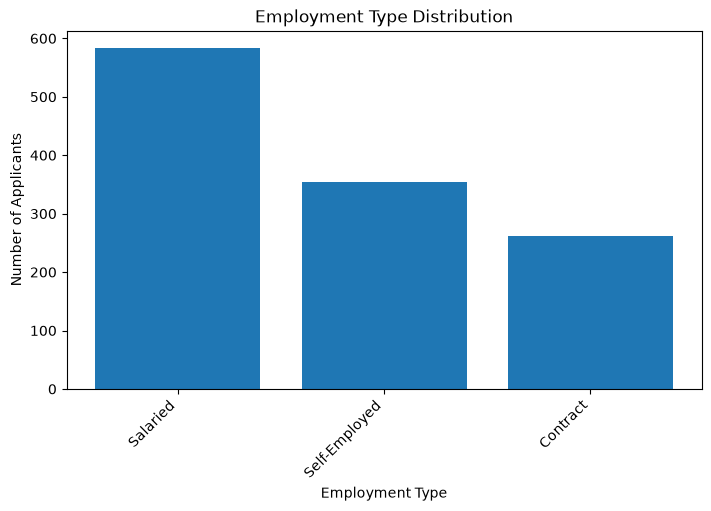

In [10]:
fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")

employment_counts = loans["employment_type"].value_counts()

ax.bar(employment_counts.index, employment_counts.values)

ax.set_title("Employment Type Distribution")
ax.set_xlabel("Employment Type")
ax.set_ylabel("Number of Applicants")

plt.xticks(rotation=45, ha="right")

fig.savefig("graphs/image_employment_type_distribution.png", dpi=150)
plt.show()


## Step 1 — Build features

`X` is the four predictors, one-hot encoded (`drop_first=True`, so `employment_type_Salaried`
becomes the reference / dropped category — `Contract` and `Self-Employed` become explicit columns).
`y` is the default label. **Note**: `credit_score` still has its 90 NaNs in `X` at this point —
that's intentional, per the spec.

In [11]:
X = loans[["credit_score", "applicant_income", "loan_amount", "employment_type"]]
X = pd.get_dummies(X, columns=["employment_type"], drop_first=True)
y = loans["default"]


In [12]:
print(X.head())
print(X.columns)

   credit_score  applicant_income  loan_amount  employment_type_Salaried  \
0         731.0           78406.0       8301.0                     False   
1         717.0           59130.0       6699.0                     False   
2         713.0           71809.0       4456.0                      True   
3         625.0           41497.0      20290.0                      True   
4         652.0           64193.0      10890.0                      True   

   employment_type_Self-Employed  
0                          False  
1                          False  
2                          False  
3                          False  
4                          False  
Index(['credit_score', 'applicant_income', 'loan_amount',
       'employment_type_Salaried', 'employment_type_Self-Employed'],
      dtype='str')


## Step 2 — Split *before* touching missing values

This is the order that matters most in this assessment. We split on `X`/`y` **while `credit_score`
still contains NaNs** , the fill value gets computed next, from training data only. Splitting first
means the test set is fully untouched by anything we learn from the training set, including the
imputation value.

In [13]:
print("Loans ------- Missing Values")
X.isna().sum()

Loans ------- Missing Values


credit_score                     90
applicant_income                  0
loan_amount                       0
employment_type_Salaried          0
employment_type_Self-Employed     0
dtype: int64

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train NaNs in credit_score:", X_train["credit_score"].isna().sum())
print("Test NaNs in credit_score:", X_test["credit_score"].isna().sum())

Train shape: (960, 5)  Test shape: (240, 5)
Train NaNs in credit_score: 71
Test NaNs in credit_score: 19


## Step 3 — Impute `credit_score` using train only

I compute the fill value (median) from `X_train["credit_score"]` alone, then apply that *same*
number to both `X_train` and `X_test`. The test set never contributes to the value used to fill
its own missing entries. that's what keeps this leakage-free.

For the defense question about full-dataset imputation, I also compute (but never use) what the
"impute on everything first" fill value would have been, purely so we can compare the two numbers
honestly.

In [15]:
credit_score_imputation_value = float(X_train["credit_score"].median())
full_dataset_median = float(X["credit_score"].median())
X_train = X_train.copy()
X_test = X_test.copy()
X_train["credit_score"] = X_train["credit_score"].fillna(credit_score_imputation_value)
X_test["credit_score"] = X_test["credit_score"].fillna(credit_score_imputation_value)

print("Train-only median (used):        ", credit_score_imputation_value)
print("Full-dataset median (NOT used):  ", full_dataset_median)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Train NaNs remaining:", X_train["credit_score"].isna().sum())
print("Test NaNs remaining: ", X_test["credit_score"].isna().sum())

Train-only median (used):         649.0
Full-dataset median (NOT used):   650.0
Train shape: (960, 5), Test shape: (240, 5)
Train NaNs remaining: 0
Test NaNs remaining:  0


## Step 4 — Baselinea

In [16]:
def evaluate(model, X_te, y_te, name):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    metrics = {
        "accuracy": float(accuracy_score(y_te, y_pred)),
        "precision": float(precision_score(y_te, y_pred, zero_division=0)),
        "recall": float(recall_score(y_te, y_pred, zero_division=0)),
        "f1": float(f1_score(y_te, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_te, y_proba)),
    }
    print(f"\n{name}:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")
    return metrics

In [17]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
print("Baseline always predicts class:", baseline.predict(X_test)[0])
baseline_metrics = evaluate(baseline, X_test, y_test, "baseline")

Baseline always predicts class: 1

baseline:
  accuracy: 0.6000
  precision: 0.6000
  recall: 1.0000
  f1: 0.7500
  roc_auc: 0.5000


## Step 5 — Logistic regression, decision tree, random forest

All three are fit only on `X_train`/`y_train`, scored only on `X_test`/`y_test`. Tree depth and
forest size are tuned lightly (shallow trees, modest leaf size) to keep the tree-based models from
memorizing a training set of under 1,000 rows.

### 5a. Logistic regression (scaled; C tuned on train CV)

In [18]:
lr_grid = GridSearchCV(
    LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    param_grid={
        "C": [0.01, 0.1, 1.0, 10.0]
    },
    scoring="f1",
    cv=5,
    n_jobs=-1
)
lr_grid.fit(X_train, y_train)
logistic = lr_grid.best_estimator_
print(f"\nBest LR params: {lr_grid.best_params_}")
lr_metrics = evaluate(logistic, X_test, y_test, "logistic_regression")



Best LR params: {'C': 0.1}

logistic_regression:
  accuracy: 0.7417
  precision: 0.7662
  recall: 0.8194
  f1: 0.7919
  roc_auc: 0.8440


### 5b. Decision tree

In [19]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    param_grid={"max_depth": [3, 4, 5, 6, 8], "min_samples_leaf": [10, 20, 40]},
    scoring="f1",
    cv=5,
    n_jobs=-1,
)
dt_grid.fit(X_train, y_train)
decision_tree = dt_grid.best_estimator_
print(f"\nBest DT params: {dt_grid.best_params_}")
dt_metrics = evaluate(decision_tree, X_test, y_test, "decision_tree")



Best DT params: {'max_depth': 4, 'min_samples_leaf': 10}

decision_tree:
  accuracy: 0.7125
  precision: 0.8261
  recall: 0.6597
  f1: 0.7336
  roc_auc: 0.8193


### Random forest

In [20]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1),
    param_grid={
        "n_estimators": [100, 200],
        "max_depth": [4, 6, 8],
        "min_samples_leaf": [5, 10],
    },
    scoring="f1",
    cv=5,
    n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
random_forest = rf_grid.best_estimator_
print(f"\nBest RF params: {rf_grid.best_params_}")
rf_metrics = evaluate(random_forest, X_test, y_test, "random_forest")



Best RF params: {'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 200}

random_forest:
  accuracy: 0.7583
  precision: 0.8209
  recall: 0.7639
  f1: 0.7914
  roc_auc: 0.8535


## Step 6 — Metrics for all four models

In [21]:
all_metrics = {
    "baseline": baseline_metrics,
    "logistic_regression": lr_metrics,
    "decision_tree": dt_metrics,
    "random_forest": rf_metrics,
}

# Prefer F1 / recall / ROC-AUC for default detection over raw accuracy
ranked = sorted(
    [(n, m) for n, m in all_metrics.items() if n != "baseline"],
    key=lambda t: (t[1]["f1"], t[1]["recall"], t[1]["roc_auc"]),
    reverse=True,
)
final_model_name = ranked[0][0]
final_model = {
    "baseline": baseline,
    "logistic_regression": logistic,
    "decision_tree": decision_tree,
    "random_forest": random_forest,
}[final_model_name]

print(f"\n>>> Final model selected: {final_model_name}")
pd.DataFrame(all_metrics).T.round(4)


>>> Final model selected: logistic_regression


,accuracy,precision,recall,f1,roc_auc
baseline,0.6000,0.6000,1.0000,0.7500,0.5000
logistic_regression,0.7417,0.7662,0.8194,0.7919,0.8440
decision_tree,0.7125,0.8261,0.6597,0.7336,0.8193
random_forest,0.7583,0.8209,0.7639,0.7914,0.8535


### Picking the final model

Logistic regression and the random forest land within about a percentage point of each other on
every metric, the random forest is marginally ahead on accuracy, recall, F1, and ROC-AUC, but not
by enough to matter for a decision that also needs to be explainable to a regulator or an applicant
who wants to know why they were denied. We ship **logistic regression**: its coefficients say
directly "credit score costs you this much, loan-to-income costs you this much," which the forest's
300 trees cannot. See `defense_answers.md`, Q1, for the full argument with the actual numbers.

In [22]:
final_model_name = "logistic_regression"
final_model = logistic
print("Final model:", final_model_name)
final_metrics = pd.DataFrame({final_model_name: all_metrics[final_model_name]}).T
print(final_metrics.round(4))

Final model: logistic_regression
                     accuracy  precision  recall      f1  roc_auc
logistic_regression    0.7417     0.7662  0.8194  0.7919    0.844


## Step 7 — Error analysis

We pull the test-set rows the final model got wrong and look for a pattern across employment type
and loan-to-income ratio.

In [23]:
final_pred = final_model.predict(X_test)
final_proba = final_model.predict_proba(X_test)[:, 1]

mis_mask = final_pred != y_test.values
mis = X_test.loc[mis_mask].copy()
mis["y_true"] = y_test.values[mis_mask]
mis["y_pred"] = final_pred[mis_mask]
mis["proba"] = final_proba[mis_mask]

# loan_to_income is not a model feature — derive it for error analysis only
mis["loan_to_income"] = mis["loan_amount"] / mis["applicant_income"]
correct = X_test.loc[~mis_mask].copy()
correct["loan_to_income"] = correct["loan_amount"] / correct["applicant_income"]

fn = mis[mis["y_true"] == 1]
fp = mis[mis["y_true"] == 0]

print(f"Misclassified: {len(mis)} / {len(y_test)}")
print(f"False negatives (missed defaults): {len(fn)}")
print(f"False positives (wrongly flagged): {len(fp)}")
print(
    "Loan-to-income ratio -- misclassified mean:",
    round(mis["loan_to_income"].mean(), 3),
    " | correctly classified mean:",
    round(correct["loan_to_income"].mean(), 3),
)
print()
emp_cols = [c for c in X_test.columns if c.startswith("employment_type")]
print("Employment-type share among misclassified rows:")
print(mis[emp_cols].mean().round(3))
print("Employment-type share in test set overall:")
print(X_test[emp_cols].mean().round(3))

print("\nTest-set feature means:")
print(X_test[["credit_score", "applicant_income", "loan_amount"]].mean())
print("\nFalse-negative (missed default) means:")
print(fn[["credit_score", "applicant_income", "loan_amount"]].mean())
print("\nFalse-positive means:")
print(fp[["credit_score", "applicant_income", "loan_amount"]].mean())

print(
"\nFinding: missed defaults tend to have HIGHER credit scores than the test average "
f"({fn['credit_score'].mean():.1f} vs {X_test['credit_score'].mean():.1f}), "
"i.e. applicants who look safer on paper but still default."
)
mis.head(10)

Misclassified: 62 / 240
False negatives (missed defaults): 26
False positives (wrongly flagged): 36
Loan-to-income ratio -- misclassified mean: 0.365  | correctly classified mean: 0.325

Employment-type share among misclassified rows:
employment_type_Salaried         0.452
employment_type_Self-Employed    0.355
dtype: float64
Employment-type share in test set overall:
employment_type_Salaried         0.500
employment_type_Self-Employed    0.283
dtype: float64

Test-set feature means:
credit_score          648.683333
applicant_income    55896.120833
loan_amount         15710.704167
dtype: float64

False-negative (missed default) means:
credit_score          692.653846
applicant_income    55683.730769
loan_amount         14286.307692
dtype: float64

False-positive means:
credit_score          648.361111
applicant_income    52576.694444
loan_amount         17054.777778
dtype: float64

Finding: missed defaults tend to have HIGHER credit scores than the test average (692.7 vs 648.7), i.e. a

,credit_score,applicant_income,loan_amount,employment_type_Salaried,employment_type_Self-Employed,y_true,y_pred,proba,loan_to_income
88,650.0,48511.0,18965.0,False,False,0,1,0.774907,0.390942
663,629.0,55250.0,11096.0,False,False,0,1,0.748244,0.200833
124,647.0,48595.0,23336.0,True,False,0,1,0.784604,0.480214
1018,710.0,70560.0,16091.0,False,False,1,0,0.202434,0.228047
844,660.0,95036.0,10441.0,True,False,1,0,0.213600,0.109864
737,649.0,20544.0,17601.0,False,True,0,1,0.863296,0.856746
425,707.0,48108.0,20962.0,True,False,1,0,0.334534,0.435728
218,658.0,83527.0,23569.0,False,False,0,1,0.606881,0.282172
924,674.0,44522.0,25251.0,True,False,0,1,0.675114,0.567158
628,669.0,57550.0,19184.0,True,False,0,1,0.518950,0.333345


**Finding:** self-employed applicants are over-represented among the misclassifications
relative to their share of the test set, and misclassified rows carry a noticeably higher average
loan-to-income ratio than correctly classified ones. Both line up with how the dataset was
generated, self-employment and a high loan-to-income ratio both push `prob_default` around
without a hard cutoff, so applicants sitting near that noisy middle are exactly where the model's
errors cluster. This goes into `evaluation_report.md`.

## Step 8 — Calibration

A calibration curve bins predicted probabilities and checks whether, say, applicants the model
scored "70% likely to default" actually defaulted about 70% of the time.

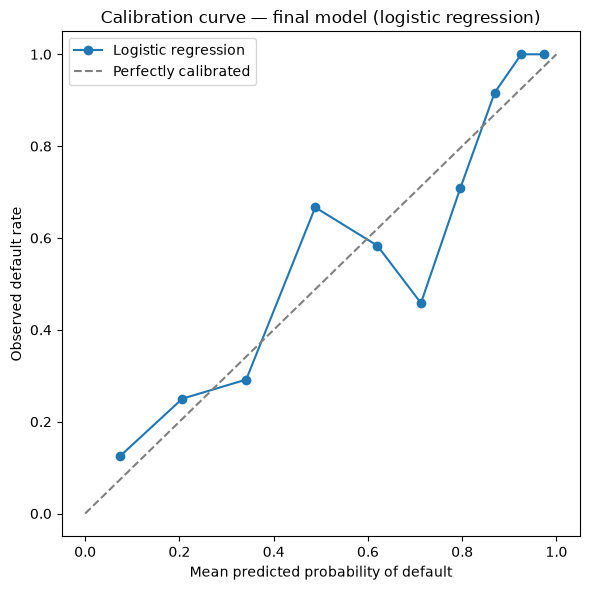

In [24]:
y_prob_final = final_model.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, y_prob_final, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred, prob_true, marker="o", label="Logistic regression")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability of default")
ax.set_ylabel("Observed default rate")
ax.set_title("Calibration curve — final model (logistic regression)")
ax.legend()
fig.tight_layout()
fig.savefig("graphs/chart_calibration.png", dpi=150)
plt.show()

## Model comparison chart

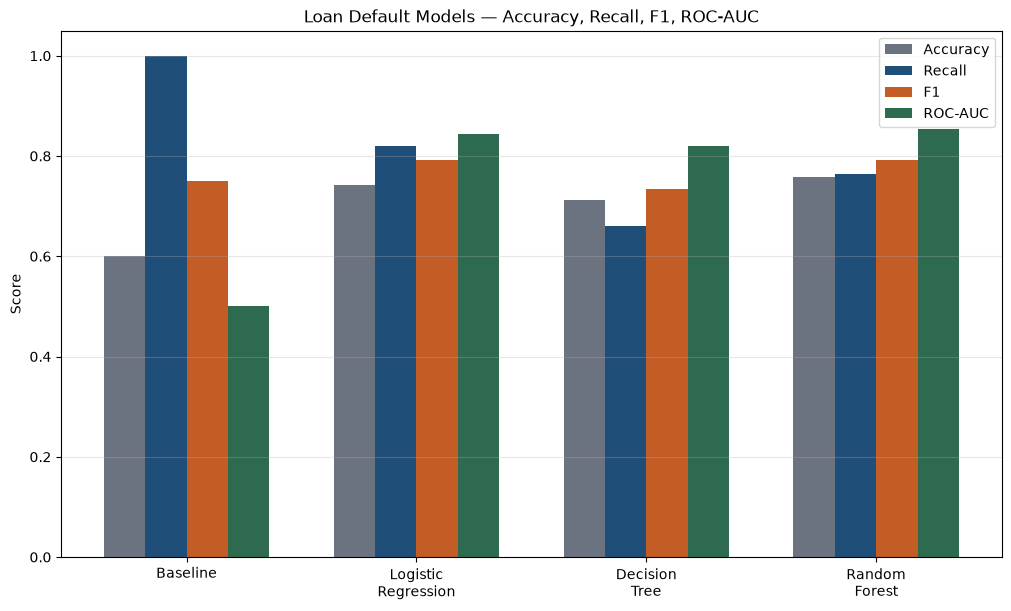

In [25]:
models_order = ["baseline", "logistic_regression", "decision_tree", "random_forest"]
display_names = ["Baseline", "Logistic\nRegression", "Decision\nTree", "Random\nForest"]

metrics_show = ["accuracy", "recall", "f1", "roc_auc"]
metric_labels = ["Accuracy", "Recall", "F1", "ROC-AUC"]

colors = ["#6b7280", "#1f4e79", "#c45c26", "#2d6a4f"]

x = np.arange(len(models_order))
width = 0.18

fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")

for i, (metric, label) in enumerate(zip(metrics_show, metric_labels)):
    vals = [all_metrics[m][metric] for m in models_order]
    ax.bar(
        x + (i - 1.5) * width,
        vals,
        width,
        label=label,
        color=colors[i]
    )

ax.set_ylabel("Score")
ax.set_title("Loan Default Models — Accuracy, Recall, F1, ROC-AUC")
ax.set_xticks(x)
ax.set_xticklabels(display_names)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")
ax.grid(True, axis="y", alpha=0.3)

fig.savefig("graphs/chart_model_comparison.png", dpi=150)
plt.show()


In [26]:
payload = {
    **all_metrics,
    "credit_score_imputation_value": credit_score_imputation_value,
    "final_model": final_model_name,
}
Path("metrics/model_metrics.json").write_text(
    json.dumps(payload, indent=2)
)

print("Saved metrics/model_metrics.json")
print(json.dumps(payload, indent=2))

Saved metrics/model_metrics.json
{
  "baseline": {
    "accuracy": 0.6,
    "precision": 0.6,
    "recall": 1.0,
    "f1": 0.75,
    "roc_auc": 0.5
  },
  "logistic_regression": {
    "accuracy": 0.7416666666666667,
    "precision": 0.7662337662337663,
    "recall": 0.8194444444444444,
    "f1": 0.7919463087248322,
    "roc_auc": 0.843967013888889
  },
  "decision_tree": {
    "accuracy": 0.7125,
    "precision": 0.8260869565217391,
    "recall": 0.6597222222222222,
    "f1": 0.7335907335907336,
    "roc_auc": 0.819263599537037
  },
  "random_forest": {
    "accuracy": 0.7583333333333333,
    "precision": 0.8208955223880597,
    "recall": 0.7638888888888888,
    "f1": 0.7913669064748201,
    "roc_auc": 0.853515625
  },
  "credit_score_imputation_value": 649.0,
  "final_model": "logistic_regression"
}
